In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv(
"../outputs/cleaned_data/featured_dataset.csv"
)

C:\Users\sushi\AppData\Local\Temp\ipykernel_17096\66973893.py:1: DtypeWarning: Columns (0: product_width_cm) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


## Executive KPIs

In [3]:
total_revenue = df["payment_value"].sum()

total_orders = df["order_id"].nunique()

total_customers = df["customer_id"].nunique()

total_products = df["product_id"].nunique()

avg_order_value = df["payment_value"].mean()

avg_delivery = df["delivery_days"].mean()

In [4]:
print(f"Total Revenue : {total_revenue:,.2f}")

print(f"Total Orders : {total_orders}")

print(f"Total Customers : {total_customers}")

print(f"Total Products : {total_products}")

print(f"Average Order Value : {avg_order_value:.2f}")

print(f"Average Delivery Days : {avg_delivery:.2f}")

Total Revenue : 20,579,664.01
Total Orders : 99441
Total Customers : 99441
Total Products : 32951
Average Order Value : 172.74
Average Delivery Days : 12.02


In [6]:
state_sales = (

df.groupby("customer_state")

["payment_value"]

.sum()

.sort_values(ascending=False)

.head(10)

)

state_sales

customer_state
SP    7726078.35
RJ    2795615.67
MG    2351221.09
RS    1160175.66
PR    1079795.49
BA     805070.98
SC     801276.45
GO     520481.65
DF     438095.32
ES     408611.64
Name: payment_value, dtype: float64

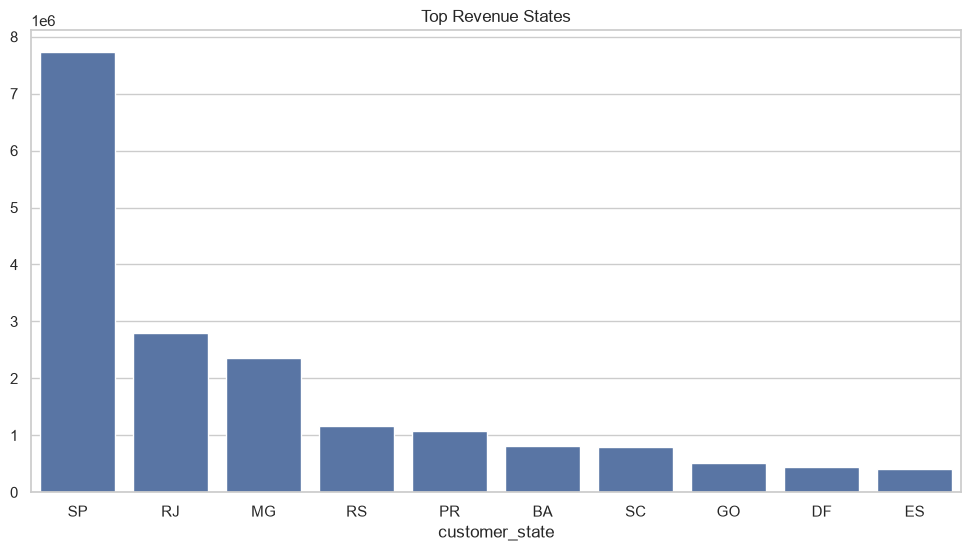

In [7]:
plt.figure(figsize=(12,6))

sns.barplot(

x=state_sales.index,

y=state_sales.values

)

plt.title("Top Revenue States")

plt.show()

In [8]:
category_sales=(

df.groupby(

"product_category_name_english"

)["payment_value"]

.sum()

.sort_values(

ascending=False

)

.head(10)

)

category_sales

product_category_name_english
bed_bath_table\r           1743998.80
health_beauty\r            1662963.59
computers_accessories\r    1599481.06
furniture_decor\r          1443963.61
watches_gifts\r            1430553.48
sports_leisure\r           1400223.07
housewares\r               1097900.09
auto\r                      855095.68
garden_tools\r              840721.59
cool_stuff\r                781933.97
Name: payment_value, dtype: float64

) missing from font(s) Arial.op\AI_retail_analytics\myvenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


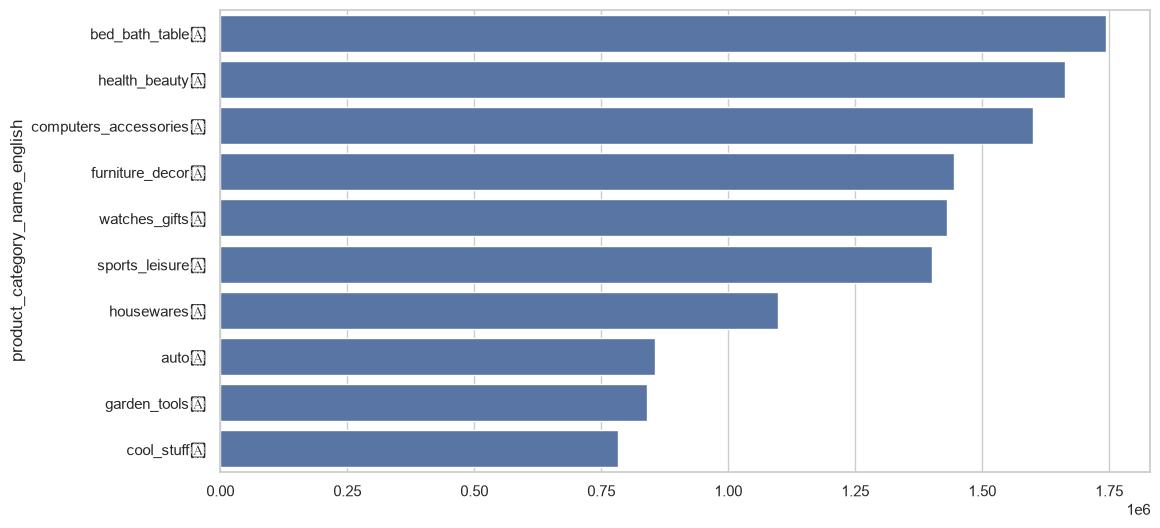

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(

x=category_sales.values,

y=category_sales.index

)

plt.show()

In [10]:
seller_sales=(

df.groupby("seller_id")

["payment_value"]

.sum()

.sort_values(

ascending=False

)

.head(10)

)

seller_sales

seller_id
7c67e1448b00f6e969d365cea6b010ab    512645.19
1025f0e2d44d7041d6cf58b6550e0bfa    312456.49
4a3ca9315b744ce9f8e9374361493884    306138.80
1f50f920176fa81dab994f9023523100    291918.98
53243585a1d6dc2643021fd1853d8905    284903.08
da8622b14eb17ae2831f4ac5b9dab84a    276578.63
4869f7a5dfa277a7dca6462dcf3b52b2    264166.12
955fee9216a65b617aa5c0531780ce60    236414.48
fa1c13f2614d7b5c4749cbc52fecda94    206513.23
7e93a43ef30c4f03f38b393420bc753a    185134.21
Name: payment_value, dtype: float64

In [11]:
monthly=(

df.groupby(

"order_month_name"

)["payment_value"]

.sum()

)

monthly

order_month_name
April        2012499.64
August       2133110.99
December     1060969.25
February     1679187.10
January      1616267.67
July         2111509.92
June         1913460.58
March        2034439.48
May          2249436.06
November     1610581.21
October      1123232.13
September    1034969.98
Name: payment_value, dtype: float64

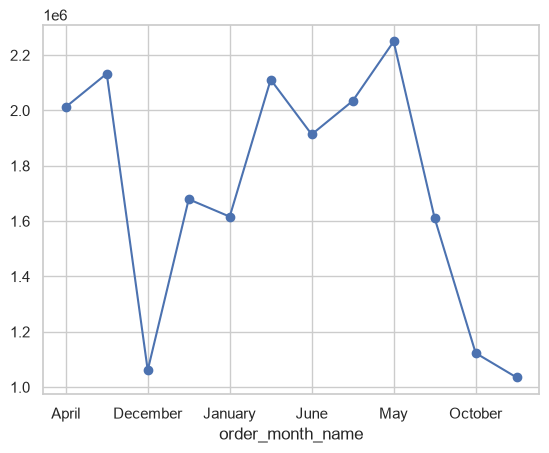

In [12]:
monthly.plot(

marker="o"

)

plt.show()

In [13]:
delivery=(

df["delivery_status"]

.value_counts()

)

delivery

delivery_status
On Time    111584
Late         7559
Name: count, dtype: int64

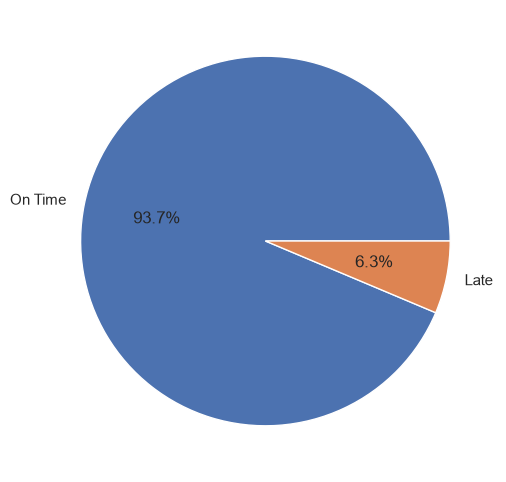

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(

delivery,

labels=delivery.index,



)

plt.show()

In [15]:
review=df[

"review_category"

].value_counts()

review

review_category
Positive    88660
Negative    20589
Neutral      9894
Name: count, dtype: int64

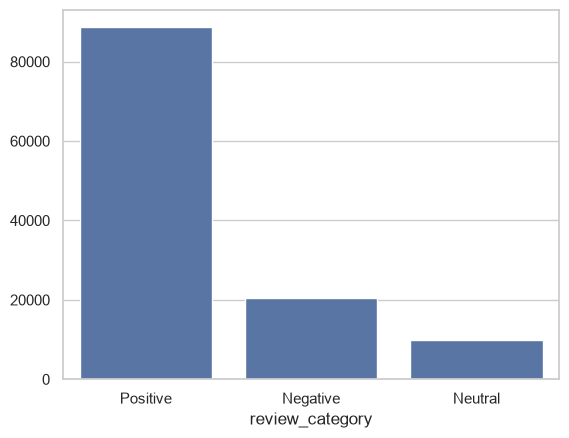

In [16]:
sns.barplot(

x=review.index,

y=review.values

)

plt.show()

In [20]:
payment=df.groupby(

"payment_type"

)["payment_value"].sum()

payment

payment_type
boleto          4110920.74
credit_card    15775450.54
debit_card       257374.89
not_defined           0.00
voucher          435917.84
Name: payment_value, dtype: float64

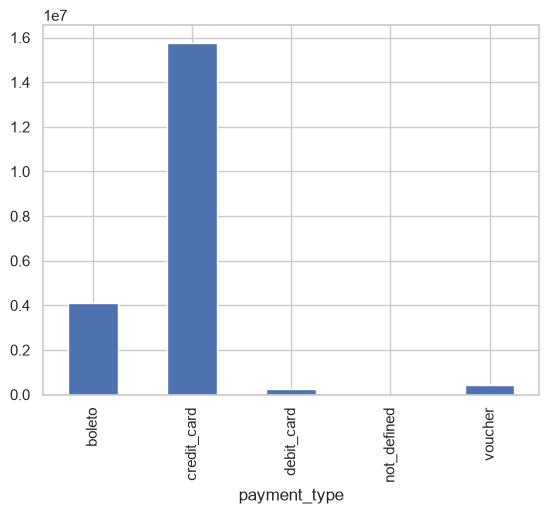

In [21]:
payment.plot(

kind="bar"

)

plt.show()

In [19]:
top_customers=(

df.groupby(

"customer_unique_id"

)["payment_value"]

.sum()

.sort_values(

ascending=False

)

.head(10)

)

top_customers

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    109312.64
698e1cf81d01a3d389d96145f7fa6df8     45256.00
c402f431464c72e27330a67f7b94d4fb     44048.00
4007669dec559734d6f53e029e360987     36489.24
ef8d54b3797ea4db1d63f0ced6a906e9     30186.00
763c8b1c9c68a0229c42c9fc6f662b93     29099.52
c8460e4251689ba205045f3ea17884a1     27935.46
eae0a83d752b1dd32697e0e7b4221656     25051.89
3d47f4368ccc8e1bb4c4a12dbda7111b     22346.60
adfa1cab2b2c8706db21bb13c0a1beb1     19457.04
Name: payment_value, dtype: float64

# Business Insights

## Executive Summary

- Total Revenue Generated

- Total Orders

- Total Customers

- Average Delivery Time

- Top Revenue State

- Top Category

- Top Seller

- Most Used Payment Method

- Average Rating

- Customer Satisfaction Level